# Experiment No 4 :DataAnalytics I
Create a Linear Regression Model using Python/R to predict home prices using Boston Housing Dataset (https://www.kaggle.com/c/boston-housing). The Boston Housing dataset contains information about various houses in Boston through different parameters.
There are 506 samples and 13 feature variables in this dataset.
The objective is to predict the value of prices of the house using the given features.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split

In [5]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Define feature names as provided in the dataset description or common usage
feature_names = np.array(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
                          'TAX', 'PTRATIO', 'B', 'LSTAT'])

# Recreate a 'boston' object as a dictionary to mimic the structure previously used
boston = {
    'data': data,
    'target': target,
    'feature_names': feature_names,
    'DESCR': 'Boston Housing Dataset (loaded from original source due to sklearn deprecation)',
    'filename': data_url
}

print(boston['data'].shape)

(506, 13)


In [4]:
# The boston object is loaded in the previous cell.
# Print the content of the boston dictionary.
print(boston)

{'data': array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 1.5300e+01, 3.9690e+02,
        4.9800e+00],
       [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9690e+02,
        9.1400e+00],
       [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9283e+02,
        4.0300e+00],
       ...,
       [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        5.6400e+00],
       [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9345e+02,
        6.4800e+00],
       [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        7.8800e+00]]), 'target': array([24. , 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9, 15. ,
       18.9, 21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 18.2, 13.6, 19.6,
       15.2, 14.5, 15.6, 13.9, 16.6, 14.8, 18.4, 21. , 12.7, 14.5, 13.2,
       13.1, 13.5, 18.9, 20. , 21. , 24.7, 30.8, 34.9, 26.6, 25.3, 24.7,
       21.2, 19.3, 20. , 16.6, 14.4, 19.4, 19.7, 20.5, 25. , 23.4, 18.9,
       35.4, 24.7, 31.6, 23.3, 19.6, 1

In [6]:
boston['feature_names']

array(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
       'TAX', 'PTRATIO', 'B', 'LSTAT'], dtype='<U7')

In [7]:
boston['target']

array([24. , 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9, 15. ,
       18.9, 21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 18.2, 13.6, 19.6,
       15.2, 14.5, 15.6, 13.9, 16.6, 14.8, 18.4, 21. , 12.7, 14.5, 13.2,
       13.1, 13.5, 18.9, 20. , 21. , 24.7, 30.8, 34.9, 26.6, 25.3, 24.7,
       21.2, 19.3, 20. , 16.6, 14.4, 19.4, 19.7, 20.5, 25. , 23.4, 18.9,
       35.4, 24.7, 31.6, 23.3, 19.6, 18.7, 16. , 22.2, 25. , 33. , 23.5,
       19.4, 22. , 17.4, 20.9, 24.2, 21.7, 22.8, 23.4, 24.1, 21.4, 20. ,
       20.8, 21.2, 20.3, 28. , 23.9, 24.8, 22.9, 23.9, 26.6, 22.5, 22.2,
       23.6, 28.7, 22.6, 22. , 22.9, 25. , 20.6, 28.4, 21.4, 38.7, 43.8,
       33.2, 27.5, 26.5, 18.6, 19.3, 20.1, 19.5, 19.5, 20.4, 19.8, 19.4,
       21.7, 22.8, 18.8, 18.7, 18.5, 18.3, 21.2, 19.2, 20.4, 19.3, 22. ,
       20.3, 20.5, 17.3, 18.8, 21.4, 15.7, 16.2, 18. , 14.3, 19.2, 19.6,
       23. , 18.4, 15.6, 18.1, 17.4, 17.1, 13.3, 17.8, 14. , 14.4, 13.4,
       15.6, 11.8, 13.8, 15.6, 14.6, 17.8, 15.4, 21

In [8]:
print(boston['data'].shape) # .shape → returns (number_of_rows, number_of_columns)

(506, 13)


#  Decription of following each key means
data → Feature values (506 × 13 matrix)
target → House prices (median value)
feature_names → Names of the 13 input features
DESCR → Detailed description of the dataset
filename → Path of the dataset file

In [9]:
# The boston object is loaded in a previous cell.
# Print the keys of the boston dictionary.
print(boston.keys())

dict_keys(['data', 'target', 'feature_names', 'DESCR', 'filename'])


#Decription of following Code
x = pd.DataFrame(boston.data, columns=boston.feature_names)
Converts the feature data into a Pandas DataFrame
Rows → 506 houses
Columns → 13 housing features
Each column represents an independent variable, such as:
CRIM – Crime rate
RM – Average number of rooms
LSTAT – % lower status population etc.


y = pd.DataFrame(boston.target)

Converts the target values into a DataFrame

Contains house prices (median value of owner-occupied homes)

➡️ y is the output (dependent variable).

In [10]:
x = pd.DataFrame(boston['data'], columns = boston['feature_names'])
y = pd.DataFrame(boston['target']) #The model learns the relationship: 𝑦=𝑓(𝑋)

In [11]:
x.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3.0,222.0,18.7,394.12,5.21
6,0.08829,12.5,7.87,0.0,0.524,6.012,66.6,5.5605,5.0,311.0,15.2,395.60,12.43
7,0.14455,12.5,7.87,0.0,0.524,6.172,96.1,5.9505,5.0,311.0,15.2,396.90,19.15
8,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5.0,311.0,15.2,386.63,29.93
9,0.17004,12.5,7.87,0.0,0.524,6.004,85.9,6.5921,5.0,311.0,15.2,386.71,17.10


In [12]:
y.head(10)

,0
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2
5,28.7
6,22.9
7,27.1
8,16.5
9,18.9


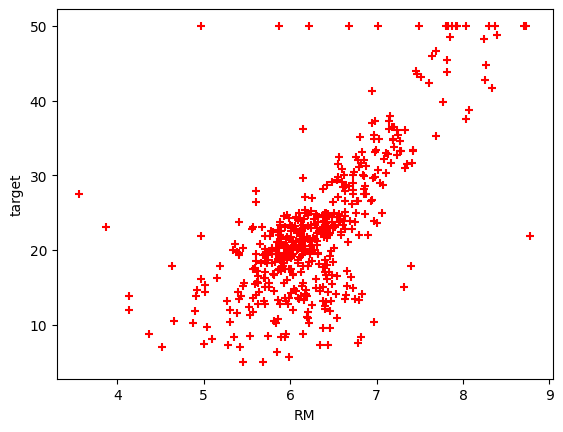

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.xlabel('RM')  #plt.xlabel() → single label only
plt.ylabel('target')
#plt.scatter(x, y, ...) → all arguments inside the same parentheses
plt.scatter(boston['data'][:, 5], boston['target'], color='red', marker='+') #boston.data[:, 5] → RM feature (average number of rooms)
#boston.target → house price
plt.show()

In [14]:
reg = linear_model.LinearRegression()

##  Decription of following  
x → input features (housing characteristics)
y → target values (house prices)
test_size=0.20 →
80% data → training
20% data → testing
random_state=42 → ensures same split every time (reproducibility)
Train the model on one part of the data and test its performance on unseen data.

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [16]:
reg.fit(x_train, y_train)#The model learns  how each housing feature affects the house price , optimal coefficients and intercept
 # Price=b0+b1x1+b2x2+⋯+b13x13

LinearRegression()

# Description of following code
Positive coefficient → Feature increases house price
(e.g., more rooms → higher price)

Negative coefficient → Feature decreases house price
(e.g., higher crime rate → lower price)

In [17]:
print(reg.coef_) # Print coefiicients in house price prediction, coefficients represent how much the house price changes when a particular feature increases by 1 unit, keeping all other features constant.

[[-1.13055924e-01  3.01104641e-02  4.03807204e-02  2.78443820e+00
  -1.72026334e+01  4.43883520e+00 -6.29636221e-03 -1.44786537e+00
   2.62429736e-01 -1.06467863e-02 -9.15456240e-01  1.23513347e-02
  -5.08571424e-01]]


# The model learns the relationship between housing features and house prices by estimating coefficients and intercept.
R² measures how well the model explains the variation in house prices.
R² = 1.0 → Perfect prediction
R² = 0.0 → Model predicts no better than mean
R² < 0 → Very poor model
The model explains 66% of the variation in house prices using the given features.

In [18]:
reg.fit(x_train, y_train)# Trains the Linear Regression model using the training data.
print(reg.score(x_test, y_test)) #Returns the R² score (coefficient of determination) of the model on test data.

0.6687594935356326


In [19]:
y_pred = reg.predict(x_test) #Uses the trained Linear Regression model to predict house prices.
#Predictions are made for the test dataset, which the model has not seen during training.

print(y_pred) #y_pred contains the predicted house prices.Each value corresponds to one house in x_test.


[[28.99672362]
 [36.02556534]
 [14.81694405]
 [25.03197915]
 [18.76987992]
 [23.25442929]
 [17.66253818]
 [14.34119   ]
 [23.01320703]
 [20.63245597]
 [24.90850512]
 [18.63883645]
 [-6.08842184]
 [21.75834668]
 [19.23922576]
 [26.19319733]
 [20.64773313]
 [ 5.79472718]
 [40.50033966]
 [17.61289074]
 [27.24909479]
 [30.06625441]
 [11.34179277]
 [24.16077616]
 [17.86058499]
 [15.83609765]
 [22.78148106]
 [14.57704449]
 [22.43626052]
 [19.19631835]
 [22.43383455]
 [25.21979081]
 [25.93909562]
 [17.70162434]
 [16.76911711]
 [16.95125411]
 [31.23340153]
 [20.13246729]
 [23.76579011]
 [24.6322925 ]
 [13.94204955]
 [32.25576301]
 [42.67251161]
 [17.32745046]
 [27.27618614]
 [16.99310991]
 [14.07009109]
 [25.90341861]
 [20.29485982]
 [29.95339638]
 [21.28860173]
 [34.34451856]
 [16.04739105]
 [26.22562412]
 [39.53939798]
 [22.57950697]
 [18.84531367]
 [32.72531661]
 [25.0673037 ]
 [12.88628956]
 [22.68221908]
 [30.48287757]
 [31.52626806]
 [15.90148607]
 [20.22094826]
 [16.71089812]
 [20.52384